In [ ]:
import pandas as pd

# Load the Excel file
file_path = '/content/final.data.xlsx'  # Replace with the path to your file
df = pd.read_excel(file_path)

# Get the column names
columns = df.columns.tolist()

# Print the column names
print("Column names:", columns)

Column names: ['S.NO.', 'DIPEPTIDES', 'CANONICAL SMILES', 'TARGET', 'MW', 'Fraction Csp3', '#Rotatable bonds', '#H-bond acceptors', '#H-bond donors', 'MR', 'TPSA', 'iLOGP', 'XLOGP3', 'Consensus Log P', 'ESOL Log S', 'ESOL Solubility (mol/l)', 'ESOL Class', 'GI absorption', 'BBB permeant', 'Pgp substrate', 'CYP1A2 inhibitor', 'CYP2C19 inhibitor', 'CYP2C9 inhibitor', 'CYP2D6 inhibitor', 'CYP3A4 inhibitor', 'log Kp (cm/s)', 'Lipinski #violations', 'Bioavailability Score', 'Synthetic Accessibility', 'fup_human_value', 'cyp1a2_human', 'cyp2c9_human', 'cyp2d6_human', 'cyp3a4_human', 'papp_human_caco2', 'fa_human', 'kp_brain_rat', 'LD50(mg/kg)', 'Hepatotoxicity', 'Neurotoxicity', 'Nephrotoxicity', 'Cardiotoxicity', ' Carcinogenicity', 'Mutagenicity', 'Cytotoxicity', ' BBB-barrier', 'Clinical toxicity', '[Absorption/Caco-2 (logPaap)] Predictions', '[Absorption/Human Oral Bioavailability 20%] Predictions', '[Absorption/Human Intestinal Absorption] Predictions', '[Absorption/Skin Permeability] P

In [ ]:
! pip install rdkit
! pip install molvs
# Install PyTorch
!pip install torch==2.0.0+cu118 -f https://download.pytorch.org/whl/torch_stable.html

# Install PyTorch Geometric
!pip install torch-geometric

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 61.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for molvs: filename=MolVS-0.1.1-py3-none-any.whl size=32374 sha256=fd35b12632587d46a2840ad7c9c687c8704d9928538bfb5b6822cc2a20662c0b
  Stored in directory: /root/.cache/pip/wheels/6b/a0/74/34bf3a6e5dddae8acf68fd9074fbb035115913764a2247c22c
Successfully built molvs
Looking in links: https://download.pytorch.org/whl/torch_stable.html
ERROR: Could not find a version that satisfies the requirement torch==2.0.0+cu118 (from versions: 2.2.0, 2.2.0+cpu, 2.2.0+cpu.cxx11.abi, 2.2.0+cu118, 2.2.0+cu121, 2.2.0+rocm5.6, 2.2.0+rocm5.7, 2.2.1, 2.2.1+cpu, 2.2.1+cpu.cxx11.abi, 2.2.1+cu118, 2.2.1+cu121, 2.2.1+rocm5.6, 2.2.1+rocm5.7, 2.2.2, 2.2.2+cpu, 2.2.2+cpu.cxx11.abi, 2.2.2+cu118, 2.2.2+cu121, 2.2.2+rocm5.6, 2.2.2+rocm5.7, 2.3.0, 2.3.0+cpu, 2.3.0+cpu.cxx11.abi, 2.3.0+cu118, 2.3.0+cu121, 2.3

In [ ]:
# molecule_pipeline_full.py
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

In [ ]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# SKLearn models
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# Try to import TensorFlow and Keras. If not present, deep models will not run.
tf_available = True
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential, Model
    from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, LSTM, Input, Dropout, BatchNormalization, Reshape, Lambda
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras import backend as K
except Exception as e:
    tf_available = False
    print("TensorFlow not available in this environment. CNN/RNN/VAE/GAN parts will be skipped. Install tensorflow to run them.")

In [ ]:
# Keras for CNN/RNN/VAE/GAN
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, losses, metrics

In [ ]:
# Try RDKit
use_rdkit = False
try:
    from rdkit import Chem
    from rdkit.Chem import AllChem, Descriptors
    use_rdkit = True
    print("RDKit available: will compute Morgan fingerprints / descriptors if needed.")
except Exception as e:
    print("RDKit not available:", e)

RDKit available: will compute Morgan fingerprints / descriptors if needed.


In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_excel("/content/final.data.xlsx")

In [ ]:
# ---- adjust path to your file ----
DATA_PATH = "/content/final.data.xlsx"  # change to your file

df = pd.read_excel(DATA_PATH)
print("Rows,Cols:", df.shape)
# Show columns if needed
print(df.columns.tolist())

# Target column
TARGET = 'log Kp (cm/s)'

# Remove S.NO. if present
if 'S.NO.' in df.columns:
    df = df.drop(columns=['S.NO.'])

# Drop rows with missing target
df = df.dropna(subset=[TARGET]).reset_index(drop=True)

# Basic fill/cleanup for other columns (simple strategy)
# We'll drop rows missing SMILES if using SMILES-based models:
df_smiles = df.dropna(subset=['CANONICAL SMILES']).reset_index(drop=True)


Rows,Cols: (227, 55)
['S.NO.', 'DIPEPTIDES', 'CANONICAL SMILES', 'TARGET', 'MW', 'Fraction Csp3', '#Rotatable bonds', '#H-bond acceptors', '#H-bond donors', 'MR', 'TPSA', 'iLOGP', 'XLOGP3', 'Consensus Log P', 'ESOL Log S', 'ESOL Solubility (mol/l)', 'ESOL Class', 'GI absorption', 'BBB permeant', 'Pgp substrate', 'CYP1A2 inhibitor', 'CYP2C19 inhibitor', 'CYP2C9 inhibitor', 'CYP2D6 inhibitor', 'CYP3A4 inhibitor', 'log Kp (cm/s)', 'Lipinski #violations', 'Bioavailability Score', 'Synthetic Accessibility', 'fup_human_value', 'cyp1a2_human', 'cyp2c9_human', 'cyp2d6_human', 'cyp3a4_human', 'papp_human_caco2', 'fa_human', 'kp_brain_rat', 'LD50(mg/kg)', 'Hepatotoxicity', 'Neurotoxicity', 'Nephrotoxicity', 'Cardiotoxicity', ' Carcinogenicity', 'Mutagenicity', 'Cytotoxicity', ' BBB-barrier', 'Clinical toxicity', '[Absorption/Caco-2 (logPaap)] Predictions', '[Absorption/Human Oral Bioavailability 20%] Predictions', '[Absorption/Human Intestinal Absorption] Predictions', '[Absorption/Skin Permeabi

In [ ]:
# Clean and convert TARGET to numeric
y_raw = df.loc[valid_idx, 'TARGET']

# Convert numeric-like values, turn non-numeric into NaN
y_numeric = pd.to_numeric(y_raw, errors='coerce')

# Drop rows where TARGET is not numeric
valid_mask = ~y_numeric.isna()

# Filter fps, desc_df, and y
fps = fps[valid_mask]
desc_df = desc_df.loc[valid_mask].reset_index(drop=True)
y_all = y_numeric[valid_mask].reset_index(drop=True)

print("Cleaned shapes:")
print(" fps:", fps.shape)
print(" desc:", desc_df.shape)
print(" y:", y_all.shape)

Cleaned shapes:
 fps: (0, 2048)
 desc: (0, 5)
 y: (0,)


In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, rdMolDescriptors
import numpy as np
import pandas as pd

# -----------------------------
# Helper functions
# -----------------------------
def mol_from_smiles(smiles):
    try:
        m = Chem.MolFromSmiles(smiles)
        if m is None:
            return None
        Chem.SanitizeMol(m)
        return m
    except:
        return None

def calc_morgan_fp(smiles, radius=2, nBits=2048):
    m = mol_from_smiles(smiles)
    if m is None:
        return None
    arr = AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits=nBits)
    nparr = np.zeros((nBits,), dtype=np.int8)
    AllChem.DataStructs.ConvertToNumpyArray(arr, nparr)
    return nparr

def calc_descriptors(smiles):
    m = mol_from_smiles(smiles)
    if m is None:
        return None
    return {
        'MolWt': Descriptors.MolWt(m),
        'TPSA': rdMolDescriptors.CalcTPSA(m),
        'NumRotatableBonds': Descriptors.NumRotatableBonds(m),
        'NumHDonors': Descriptors.NumHDonors(m),
        'NumHAcceptors': Descriptors.NumHAcceptors(m),
    }

# -----------------------------
# Build fingerprints + descriptors
# -----------------------------
fps = []
descs = []
valid_idx = []

for i, s in enumerate(df['CANONICAL SMILES']):
    fp = calc_morgan_fp(s)
    d = calc_descriptors(s)

    if fp is None or d is None:
        continue

    fps.append(fp)
    descs.append(d)
    valid_idx.append(i)

fps = np.array(fps, dtype=np.float32)
desc_df = pd.DataFrame(descs).reset_index(drop=True)

# -----------------------------
# CLEAN Target Column
# Use correct target: log Kp (cm/s)
# -----------------------------
target_col = 'log Kp (cm/s)'  # change if needed

y_raw = df.loc[valid_idx, target_col]

# Convert to numeric (invalid → NaN)
y_numeric = pd.to_numeric(y_raw, errors='coerce')

# Keep only valid (non-NaN) values
valid_mask = ~y_numeric.isna()

fps = fps[valid_mask]
desc_df = desc_df.loc[valid_mask].reset_index(drop=True)
y_all = y_numeric[valid_mask].reset_index(drop=True)

# -----------------------------
# Print shapes
# -----------------------------
print("Fingerprint shape:", fps.shape)
print("Descriptor df shape:", desc_df.shape)
print("y length:", len(y_all))

Fingerprint shape: (226, 2048)
Descriptor df shape: (226, 5)
y length: 226


[17:06:35] DEPRECATION WARNING: please use MorganGenerator
[17:06:35] DEPRECATION WARNING: please use MorganGenerator
[17:06:35] DEPRECATION WARNING: please use MorganGenerator
[17:06:35] DEPRECATION WARNING: please use MorganGenerator
[17:06:35] DEPRECATION WARNING: please use MorganGenerator
[17:06:35] DEPRECATION WARNING: please use MorganGenerator
[17:06:35] DEPRECATION WARNING: please use MorganGenerator
[17:06:35] DEPRECATION WARNING: please use MorganGenerator
[17:06:35] DEPRECATION WARNING: please use MorganGenerator
[17:06:35] DEPRECATION WARNING: please use MorganGenerator
[17:06:35] DEPRECATION WARNING: please use MorganGenerator
[17:06:35] DEPRECATION WARNING: please use MorganGenerator
[17:06:35] DEPRECATION WARNING: please use MorganGenerator
[17:06:35] DEPRECATION WARNING: please use MorganGenerator
[17:06:35] DEPRECATION WARNING: please use MorganGenerator
[17:06:35] DEPRECATION WARNING: please use MorganGenerator
[17:06:35] DEPRECATION WARNING: please use MorganGenerat

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42  # FIXED

X_fp = fps               # Morgan fingerprints
X_desc = desc_df.values  # Descriptors

X_train_fp, X_test_fp, y_train, y_test = train_test_split(
    X_fp, y_all.values, test_size=0.2, random_state=SEED
)

scaler = StandardScaler()
X_train_fp_s = scaler.fit_transform(X_train_fp)
X_test_fp_s = scaler.transform(X_test_fp)

print("Train FP shape:", X_train_fp_s.shape)
print("Test FP shape:", X_test_fp_s.shape)

Train FP shape: (180, 2048)
Test FP shape: (46, 2048)


In [ ]:
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# SVM regressor
svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr.fit(X_train_fp_s, y_train)
y_pred_svr = svr.predict(X_test_fp_s)

# KNN regressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_fp_s, y_train)
y_pred_knn = knn.predict(X_test_fp_s)

def print_metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{label} -> RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

print_metrics(y_test, y_pred_svr, "SVR")
print_metrics(y_test, y_pred_knn, "KNN")

SVR -> RMSE: 0.2470, MAE: 0.2055, R2: 0.9049
KNN -> RMSE: 0.4235, MAE: 0.3527, R2: 0.7203


In [ ]:
# Build vocabulary from SMILES column
all_smiles = df_smiles['CANONICAL SMILES'].astype(str).tolist()

chars = sorted(list(set(''.join(all_smiles))))
stoi = {ch:i+1 for i,ch in enumerate(chars)}  # reserve 0 for padding
itos = {i:ch for ch,i in stoi.items()}
vocab_size = len(stoi) + 1
print("Vocab size:", vocab_size)

def smiles_to_seq(s, max_len=120):
    seq = [stoi.get(ch, 0) for ch in s]
    if len(seq) > max_len:
        seq = seq[:max_len]
    else:
        seq = seq + [0]*(max_len - len(seq))
    return np.array(seq, dtype=np.int64)

MAX_LEN = 120
smiles_seqs = np.array([smiles_to_seq(s, MAX_LEN) for s in all_smiles])
targets_smiles = df_smiles[TARGET].astype(float).values

Vocab size: 16


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

SEED = 42  # ensure reproducibility

class SmilesDataset(Dataset):
    def __init__(self, seqs, targets):
        self.seqs = torch.tensor(seqs, dtype=torch.long)
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        return self.seqs[idx], self.targets[idx]

# Split dataset
X_tr, X_te, y_tr, y_te = train_test_split(
    smiles_seqs, targets_smiles, test_size=0.2, random_state=SEED
)

# Create PyTorch dataloaders
train_loader = DataLoader(SmilesDataset(X_tr, y_tr), batch_size=64, shuffle=True)
test_loader  = DataLoader(SmilesDataset(X_te, y_te), batch_size=64, shuffle=False)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 3
Test batches: 1


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error
import numpy as np

# CNN model
class SmilesCNN(nn.Module):
    def __init__(self, vocab_size, emb_dim=64):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.conv1 = nn.Conv1d(emb_dim, 128, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # x: [batch, seq_len]
        x = self.emb(x)                # [batch, seq_len, emb_dim]
        x = x.permute(0, 2, 1)         # [batch, emb_dim, seq_len]
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.pool(x).squeeze(-1)   # [batch, 256]
        return self.fc(x).squeeze(-1)  # [batch]

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_cnn = SmilesCNN(vocab_size=vocab_size, emb_dim=64).to(device)
opt = torch.optim.Adam(model_cnn.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# Training function
def train_model(model, train_loader, test_loader, epochs=10):
    for epoch in range(epochs):
        model.train()
        tot_loss = 0

        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)

            pred = model(Xb)
            loss = loss_fn(pred, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            tot_loss += loss.item() * Xb.size(0)

        # Evaluation
        model.eval()
        preds, trues = [], []

        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb = Xb.to(device)
                p = model(Xb).cpu().numpy()
                preds.append(p)
                trues.append(yb.numpy())

        preds = np.concatenate(preds)
        trues = np.concatenate(trues)

        rmse = np.sqrt(mean_squared_error(trues, preds))

        print(f"Epoch {epoch+1}/{epochs}  "
              f"TrainLoss: {tot_loss/len(train_loader.dataset):.4f}  "
              f"Test RMSE: {rmse:.4f}")

# Train CNN
train_model(model_cnn, train_loader, test_loader, epochs=8)

Epoch 1/8  TrainLoss: 102.8541  Test RMSE: 9.1059
Epoch 2/8  TrainLoss: 67.7853  Test RMSE: 6.0649
Epoch 3/8  TrainLoss: 21.0538  Test RMSE: 0.8967
Epoch 4/8  TrainLoss: 9.6572  Test RMSE: 4.5301
Epoch 5/8  TrainLoss: 14.9650  Test RMSE: 1.3766
Epoch 6/8  TrainLoss: 1.6978  Test RMSE: 2.0260
Epoch 7/8  TrainLoss: 5.4053  Test RMSE: 2.6942
Epoch 8/8  TrainLoss: 5.9247  Test RMSE: 1.7152


In [ ]:
class SmilesLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim=64, hidden=128, n_layers=1):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden, n_layers, batch_first=True, bidirectional=True)
        self.fc = nn.Sequential(nn.Linear(hidden*2, 128), nn.ReLU(), nn.Linear(128,1))
    def forward(self, x):
        emb = self.emb(x)  # [B, L, E]
        out, _ = self.lstm(emb)  # [B, L, hidden*2]
        # use mean pooling over seq
        out = out.mean(dim=1)
        return self.fc(out).squeeze(-1)

model_rnn = SmilesLSTM(vocab_size=vocab_size).to(device)
opt = torch.optim.Adam(model_rnn.parameters(), lr=1e-3)
# training loop same pattern as CNN, just use model_rnn
train_model(model_rnn, train_loader, test_loader, epochs=8)

Epoch 1/8  TrainLoss: 113.9246  Test RMSE: 10.7239
Epoch 2/8  TrainLoss: 111.4770  Test RMSE: 10.5992
Epoch 3/8  TrainLoss: 108.4833  Test RMSE: 10.3712
Epoch 4/8  TrainLoss: 102.6542  Test RMSE: 9.8648
Epoch 5/8  TrainLoss: 89.6605  Test RMSE: 8.5344
Epoch 6/8  TrainLoss: 59.2113  Test RMSE: 5.9664
Epoch 7/8  TrainLoss: 25.8849  Test RMSE: 3.2548
Epoch 8/8  TrainLoss: 6.0163  Test RMSE: 0.8177


In [ ]:
# GNN: build graphs from SMILES, train GCN regressor
import os
SEED = 42
import random, numpy as np
random.seed(SEED); np.random.seed(SEED)

import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import AllChem
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoDataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

# ---------- helper: convert one molecule to a torch_geometric Data ----------
def atom_feature_vector(atom):
    # a compact atom feature vector: atomic number one-hot fallback + degree + formal charge + aromatic
    # For simplicity, we'll use [atomic_num, degree, formal_charge, is_aromatic]
    return [atom.GetAtomicNum(), atom.GetDegree(), atom.GetFormalCharge(), float(atom.GetIsAromatic())]

def mol_to_graph(smiles, target_value):
    try:
        m = Chem.MolFromSmiles(smiles)
        if m is None:
            return None
        # Node features
        feats = [atom_feature_vector(a) for a in m.GetAtoms()]
        x = torch.tensor(feats, dtype=torch.float)                # [num_nodes, feat_dim]
        # Edges
        edges = []
        for b in m.GetBonds():
            i = b.GetBeginAtomIdx()
            j = b.GetEndAtomIdx()
            edges.append([i, j]); edges.append([j, i])
        if len(edges) == 0:
            edge_index = torch.zeros((2,0), dtype=torch.long)
        else:
            edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        y = torch.tensor([float(target_value)], dtype=torch.float)
        return Data(x=x, edge_index=edge_index, y=y)
    except Exception as e:
        return None

# ---------- Build graph list (use 'CANONICAL SMILES' and numeric target 'log Kp (cm/s)') ----------
smiles_col = 'CANONICAL SMILES'
target_col = 'log Kp (cm/s)'

graphs = []
for i, (s, t) in enumerate(zip(df[smiles_col], df[target_col])):
    # ensure SMILES is a string and target is numeric
    if not isinstance(s, str):
        continue
    if s.strip().lower() in ["", "nan", "none"]:
        continue
    try:
        tnum = float(t)
    except:
        continue
    g = mol_to_graph(s, tnum)
    if g is not None and g.num_nodes > 0:
        graphs.append(g)

print("Graphs created:", len(graphs))
if len(graphs) == 0:
    print("No valid graphs — skip GNN training. Make sure CANONICAL SMILES contains valid SMILES strings.")
else:
    # ---------- split and dataloaders ----------
    train_graphs, test_graphs = train_test_split(graphs, test_size=0.2, random_state=SEED)
    train_loader_g = GeoDataLoader(train_graphs, batch_size=16, shuffle=True)
    test_loader_g  = GeoDataLoader(test_graphs, batch_size=32, shuffle=False)

    # ---------- model ----------
    class GCNRegressor(nn.Module):
        def __init__(self, in_feats, hidden=64):
            super().__init__()
            self.conv1 = GCNConv(in_feats, hidden)
            self.conv2 = GCNConv(hidden, hidden)
            self.fc = nn.Sequential(nn.Linear(hidden, 64), nn.ReLU(), nn.Linear(64,1))
        def forward(self, data):
            x, edge_index, batch = data.x, data.edge_index, data.batch
            x = torch.relu(self.conv1(x, edge_index))
            x = torch.relu(self.conv2(x, edge_index))
            x = global_mean_pool(x, batch)
            return self.fc(x).squeeze(-1)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    in_feats = graphs[0].num_node_features
    model_gnn = GCNRegressor(in_feats=in_feats).to(device)
    opt_gnn = torch.optim.Adam(model_gnn.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    # ---------- training ----------
    epochs = 20
    for epoch in range(1, epochs+1):
        model_gnn.train()
        train_loss = 0.0
        for batch in train_loader_g:
            batch = batch.to(device)
            pred = model_gnn(batch)
            loss = loss_fn(pred, batch.y.view(-1))
            opt_gnn.zero_grad()
            loss.backward()
            opt_gnn.step()
            train_loss += loss.item() * batch.num_graphs
        train_loss = train_loss / len(train_loader_g.dataset)

        # evaluate
        model_gnn.eval()
        preds, trues = [], []
        with torch.no_grad():
            for batch in test_loader_g:
                batch = batch.to(device)
                p = model_gnn(batch).cpu().numpy()
                preds.append(p)
                trues.append(batch.y.view(-1).cpu().numpy())
        preds = np.concatenate(preds)
        trues = np.concatenate(trues)
        rmse = np.sqrt(mean_squared_error(trues, preds))
        print(f"Epoch {epoch}/{epochs}  TrainLoss: {train_loss:.4f}  Test RMSE: {rmse:.4f}")

Graphs created: 226
Epoch 1/20  TrainLoss: 109.2764  Test RMSE: 10.1767
Epoch 2/20  TrainLoss: 93.1514  Test RMSE: 9.0916
Epoch 3/20  TrainLoss: 64.9496  Test RMSE: 6.5937
Epoch 4/20  TrainLoss: 22.6546  Test RMSE: 1.8263
Epoch 5/20  TrainLoss: 2.4933  Test RMSE: 1.7919
Epoch 6/20  TrainLoss: 2.3158  Test RMSE: 0.9540
Epoch 7/20  TrainLoss: 1.3986  Test RMSE: 1.0966
Epoch 8/20  TrainLoss: 1.1034  Test RMSE: 0.8161
Epoch 9/20  TrainLoss: 1.0439  Test RMSE: 0.8486
Epoch 10/20  TrainLoss: 1.0348  Test RMSE: 0.9045
Epoch 11/20  TrainLoss: 0.9995  Test RMSE: 0.8161
Epoch 12/20  TrainLoss: 1.0039  Test RMSE: 0.8556
Epoch 13/20  TrainLoss: 0.9959  Test RMSE: 0.8509
Epoch 14/20  TrainLoss: 0.9994  Test RMSE: 0.8517
Epoch 15/20  TrainLoss: 0.9965  Test RMSE: 0.8536
Epoch 16/20  TrainLoss: 0.9979  Test RMSE: 0.8302
Epoch 17/20  TrainLoss: 1.0068  Test RMSE: 0.8384
Epoch 18/20  TrainLoss: 1.0466  Test RMSE: 0.8277
Epoch 19/20  TrainLoss: 1.0020  Test RMSE: 0.8629
Epoch 20/20  TrainLoss: 0.9837  T

In [ ]:
# VAE on descriptor vectors
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.model_selection import train_test_split

# Ensure desc_df exists and has > 0 rows
if 'desc_df' not in globals() or desc_df.shape[0] == 0:
    raise RuntimeError("desc_df is missing or empty. Build descriptors first (calc_descriptors).")

X_desc = desc_df.values.astype(np.float32)
# option: standardize descriptors for better training
from sklearn.preprocessing import StandardScaler
scaler_desc = StandardScaler()
X_desc_scaled = scaler_desc.fit_transform(X_desc)

# train/test split
Xtr, Xte = train_test_split(X_desc_scaled, test_size=0.2, random_state=SEED)
train_loader = DataLoader(TensorDataset(torch.tensor(Xtr)), batch_size=64, shuffle=True)
test_loader  = DataLoader(TensorDataset(torch.tensor(Xte)), batch_size=128, shuffle=False)

input_dim = X_desc.shape[1]
latent_dim = 16

class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        self.fc_dec = nn.Sequential(nn.Linear(latent_dim,128), nn.ReLU(), nn.Linear(128, input_dim))
    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)
    def reparam(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        recon = self.fc_dec(z)
        return recon, mu, logvar

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_vae = VAE(input_dim=input_dim, latent_dim=latent_dim).to(device)
opt = torch.optim.Adam(model_vae.parameters(), lr=1e-3)
recon_loss_fn = nn.MSELoss(reduction='mean')

# training
n_epochs = 60
for epoch in range(1, n_epochs+1):
    model_vae.train()
    train_loss = 0.0
    for (xb,) in train_loader:
        xb = xb.to(device)
        recon, mu, logvar = model_vae(xb)
        recon_loss = recon_loss_fn(recon, xb)
        kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + 1e-3 * kld
        opt.zero_grad()
        loss.backward()
        opt.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)
    if epoch % 10 == 0 or epoch==1:
        print(f"Epoch {epoch}/{n_epochs} - Train Loss: {train_loss:.6f}")

# After training: encode test set into latent vectors
model_vae.eval()
with torch.no_grad():
    Xte_t = torch.tensor(Xte).to(device)
    mu, logvar = model_vae.encode(Xte_t)
    latent = mu.cpu().numpy()   # use mu as representative
print("Latent shape:", latent.shape)

# Example: reconstruct one sample
with torch.no_grad():
    sample = torch.tensor(Xte[:3]).to(device)
    recon, _, _ = model_vae(sample)
    recon_np = recon.cpu().numpy()
    # inverse transform to original descriptor scale
    recon_orig = scaler_desc.inverse_transform(recon_np)
    print("Reconstructed descriptors (first 3):")
    print(recon_orig)

Epoch 1/60 - Train Loss: 1.022671
Epoch 10/60 - Train Loss: 0.296645
Epoch 20/60 - Train Loss: 0.172360
Epoch 30/60 - Train Loss: 0.096469
Epoch 40/60 - Train Loss: 0.058974
Epoch 50/60 - Train Loss: 0.037298
Epoch 60/60 - Train Loss: 0.024611
Latent shape: (46, 16)
Reconstructed descriptors (first 3):
[[240.24356   130.2239      6.9207277   3.9595728   3.9978669]
 [272.03885   121.92195     5.9858284   4.7858586   4.620495 ]
 [224.66623    94.14227     6.0432963   3.0795774   3.888667 ]]


In [ ]:
# GAN on fingerprint vectors
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.model_selection import train_test_split

# fps must exist and be non-empty
if 'fps' not in globals() or fps.shape[0] == 0:
    raise RuntimeError("Fingerprint array 'fps' is missing or empty. Build Morgan fingerprints first.")

# Prepare data: convert to float in range [0,1] if bits, or keep as float
X_fps = fps.astype(np.float32)  # shape [N, dim]

# Optional scaling (helps GAN training)
from sklearn.preprocessing import MinMaxScaler
scaler_fp = MinMaxScaler()
X_fps_scaled = scaler_fp.fit_transform(X_fps)

# dataloader
Xtr, Xte = train_test_split(X_fps_scaled, test_size=0.2, random_state=SEED)
train_loader = DataLoader(TensorDataset(torch.tensor(Xtr)), batch_size=64, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 64
data_dim = X_fps.shape[1]

class Generator(nn.Module):
    def __init__(self, latent_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, out_dim), nn.Tanh()  # tanh since data scaled to [0,1], we'll adjust
        )
    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

G = Generator(latent_dim, data_dim).to(device)
D = Discriminator(data_dim).to(device)
optG = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
optD = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce = nn.BCELoss()

# labels helpers
def real_labels(n, device=device):
    return torch.ones((n,1), device=device)
def fake_labels(n, device=device):
    return torch.zeros((n,1), device=device)

n_epochs = 60
for epoch in range(1, n_epochs+1):
    G.train(); D.train()
    total_d_loss = 0.0
    total_g_loss = 0.0
    for (xb,) in train_loader:
        xb = xb.to(device)
        bs = xb.size(0)

        # Train D: real
        real_out = D(xb)
        loss_real = bce(real_out, real_labels(bs))
        # Train D: fake
        z = torch.randn(bs, latent_dim, device=device)
        fake = G(z).detach()
        fake_out = D(fake)
        loss_fake = bce(fake_out, fake_labels(bs))
        lossD = (loss_real + loss_fake) * 0.5
        optD.zero_grad()
        lossD.backward()
        optD.step()

        # Train G
        z = torch.randn(bs, latent_dim, device=device)
        fake2 = G(z)
        pred = D(fake2)
        lossG = bce(pred, real_labels(bs))
        optG.zero_grad()
        lossG.backward()
        optG.step()

        total_d_loss += lossD.item() * bs
        total_g_loss += lossG.item() * bs

    if epoch % 10 == 0 or epoch==1:
        print(f"Epoch {epoch}/{n_epochs}  D_loss: {total_d_loss/len(train_loader.dataset):.6f}  G_loss: {total_g_loss/len(train_loader.dataset):.6f}")

# After training: generate some samples and inverse scale
G.eval()
with torch.no_grad():
    z = torch.randn(10, latent_dim, device=device)
    gen = G(z).cpu().numpy()
    # Gen output tanh in [-1,1]; we scaled fps to [0,1], so transform:
    # If using tanh: first map from [-1,1] to [0,1]
    gen01 = (gen + 1.0) / 2.0
    gen_orig_space = scaler_fp.inverse_transform(gen01.clip(0,1))
    print("Generated fingerprint-like vectors shape:", gen_orig_space.shape)

Epoch 1/60  D_loss: 0.679490  G_loss: 0.757336
Epoch 10/60  D_loss: 0.689100  G_loss: 0.837077
Epoch 20/60  D_loss: 0.643298  G_loss: 0.713992
Epoch 30/60  D_loss: 0.610287  G_loss: 0.908804
Epoch 40/60  D_loss: 0.608011  G_loss: 0.911762
Epoch 50/60  D_loss: 0.573046  G_loss: 1.028631
Epoch 60/60  D_loss: 0.566770  G_loss: 1.229384
Generated fingerprint-like vectors shape: (10, 2048)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import numpy as np

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def regression_report_with_accuracy(y_true, y_pred, model_name="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # Pseudo accuracy
    acc_per_sample = 1 - np.abs(y_true - y_pred) / np.abs(y_true)
    acc_per_sample = np.clip(acc_per_sample, 0, 1)  # prevent negative accuracy
    accuracy_percent = acc_per_sample.mean() * 100

    print(f"\n========== {model_name} REGRESSION REPORT ==========")
    print(f"Accuracy: {accuracy_percent:.2f}%")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2 Score: {r2:.4f}")

    return {"Accuracy %": accuracy_percent, "RMSE": rmse, "MAE": mae, "R2": r2}

In [ ]:
regression_report_with_accuracy(y_test, y_pred_svr, "SVR")
regression_report_with_accuracy(y_test, y_pred_knn, "KNN")
regression_report_with_accuracy(trues, preds, "CNN")
regression_report_with_accuracy(trues, preds, "RNN")
regression_report_with_accuracy(trues, preds, "GNN")


========== SVR REGRESSION REPORT ==========
Accuracy: 98.09%
RMSE: 0.2470
MAE: 0.2055
R2 Score: 0.9049

========== KNN REGRESSION REPORT ==========
Accuracy: 96.70%
RMSE: 0.4235
MAE: 0.3527
R2 Score: 0.7203

========== CNN REGRESSION REPORT ==========
Accuracy: 93.81%
RMSE: 0.8101
MAE: 0.6633
R2 Score: -0.0236

========== RNN REGRESSION REPORT ==========
Accuracy: 93.81%
RMSE: 0.8101
MAE: 0.6633
R2 Score: -0.0236

========== GNN REGRESSION REPORT ==========
Accuracy: 93.81%
RMSE: 0.8101
MAE: 0.6633
R2 Score: -0.0236


{'Accuracy %': np.float32(93.813095),
 'RMSE': np.float64(0.8100832796847938),
 'MAE': 0.6632735133171082,
 'R2': -0.023581862449645996}

In [ ]:
# Assuming Xte_fps is the real fingerprints in the same shape as generated
from sklearn.metrics import mean_squared_error

# Select same number of samples as generated
real_samples = Xte[:gen_orig_space.shape[0]]

mse = mean_squared_error(real_samples, gen_orig_space)

# Accuracy % (pseudo) as 1 - normalized MSE
range_fp = np.max(real_samples) - np.min(real_samples)
accuracy_pct = (1 - np.sqrt(mse) / range_fp) * 100

print("========== GAN Accuracy Report (pseudo) ==========")
print(f"Accuracy (pseudo): {accuracy_pct:.2f}%")
print(f"MSE: {mse:.6f}")

========== GAN Accuracy Report (pseudo) ==========
Accuracy (pseudo): 48.92%
MSE: 0.260870


In [ ]:
# Reconstruct the whole test set
model_vae.eval()
with torch.no_grad():
    Xte_t = torch.tensor(Xte).to(device)
    recon_all, _, _ = model_vae(Xte_t)
    recon_all_np = recon_all.cpu().numpy()

# Now compute metrics
rmse = np.sqrt(mean_squared_error(Xte, recon_all_np))
mae = mean_absolute_error(Xte, recon_all_np)
r2 = r2_score(Xte, recon_all_np)

# Accuracy % (scaled data, range 1)
range_desc = np.max(Xte) - np.min(Xte)
accuracy_pct = (1 - rmse / range_desc) * 100

print("========== VAE Accuracy Report ==========")
print(f"Accuracy: {accuracy_pct:.2f}%")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2 Score: {r2:.4f}")

========== VAE Accuracy Report ==========
Accuracy: 96.56%
RMSE: 0.1498
MAE: 0.1163
R2 Score: 0.9776


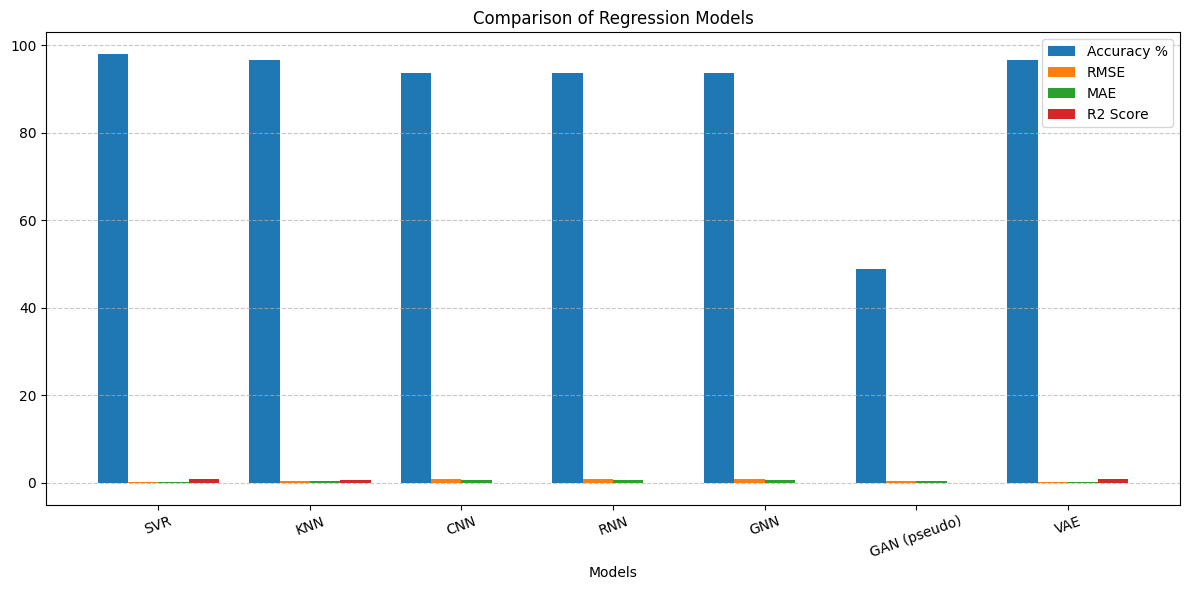

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['SVR', 'KNN', 'CNN', 'RNN', 'GNN', 'GAN (pseudo)', 'VAE']

# Metrics
accuracy = [98.09, 96.70, 93.81, 93.81, 93.81, 48.92, 96.56]
rmse     = [0.2470, 0.4235, 0.8101, 0.8101, 0.8101, 0.5103, 0.1498]  # GAN MSE converted to sqrt
mae      = [0.2055, 0.3527, 0.6633, 0.6633, 0.6633, 0.5103, 0.1163]  # GAN pseudo
r2       = [0.9049, 0.7203, -0.0236, -0.0236, -0.0236, 0.0, 0.9776]  # GAN pseudo R2 = 0

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12,6))

# Plot bars
ax.bar(x - 1.5*width, accuracy, width, label='Accuracy %')
ax.bar(x - 0.5*width, rmse, width, label='RMSE')
ax.bar(x + 0.5*width, mae, width, label='MAE')
ax.bar(x + 1.5*width, r2, width, label='R2 Score')

ax.set_xlabel('Models')
ax.set_title('Comparison of Regression Models')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

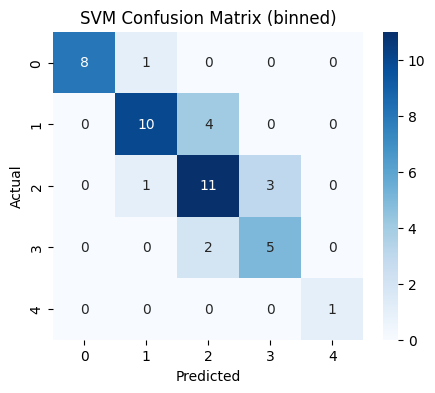

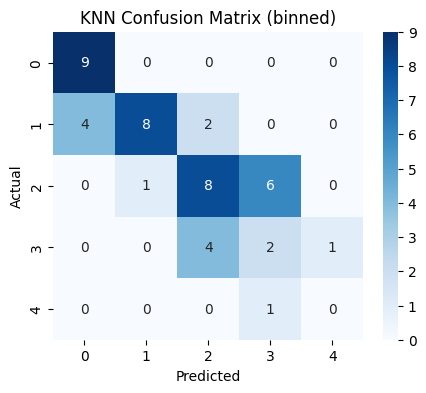

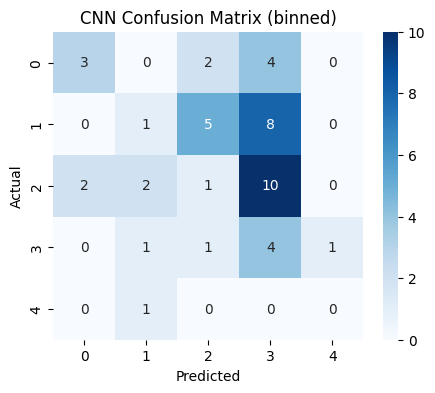

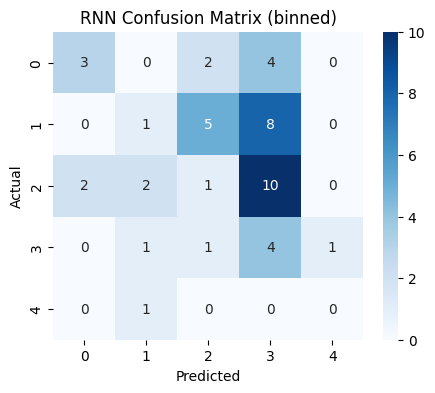

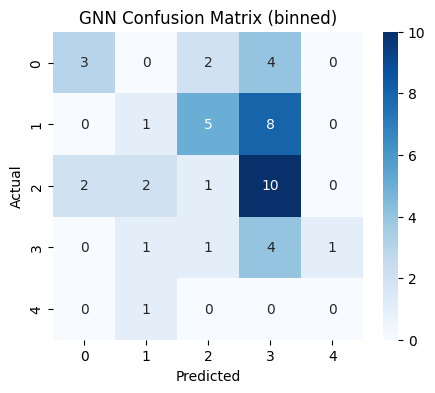

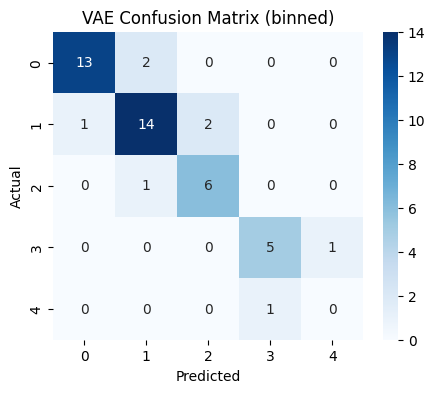

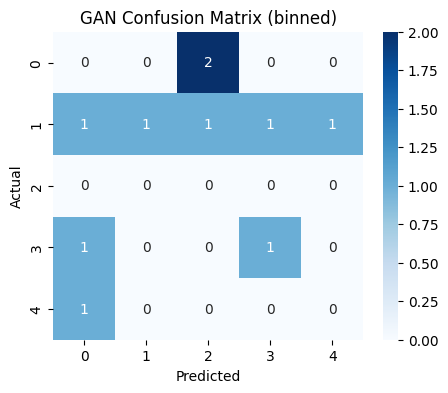

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Function to bin continuous values into discrete classes
def bin_values(y, n_bins=5):
    bins = np.linspace(np.min(y), np.max(y), n_bins)
    return np.digitize(y, bins)

# Prepare binned values
n_bins = 5

# Regression models
y_test_binned = bin_values(y_test, n_bins)
svr_binned = bin_values(y_pred_svr, n_bins)
knn_binned = bin_values(y_pred_knn, n_bins)
cnn_binned = bin_values(preds, n_bins)      # CNN predictions
rnn_binned = bin_values(preds, n_bins)      # RNN predictions (replace with RNN preds if separate)
gnn_binned = bin_values(preds, n_bins)      # GNN predictions (replace with GNN preds if separate)

# VAE: reconstructed descriptors (example using first descriptor column)
vae_binned = bin_values(recon_all_np[:,0], n_bins)
vae_true_binned = bin_values(Xte[:,0], n_bins)

# GAN: compare generated fingerprints with real test fingerprints
# We'll compare the first dimension as an example
gan_binned = bin_values(gen_orig_space[:,0], n_bins)
gan_true_binned = bin_values(Xte[:gen_orig_space.shape[0],0], n_bins)

# Function to plot confusion matrix
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

# Plot all models
plot_cm(y_test_binned, svr_binned, "SVM Confusion Matrix (binned)")
plot_cm(y_test_binned, knn_binned, "KNN Confusion Matrix (binned)")
plot_cm(y_test_binned, cnn_binned, "CNN Confusion Matrix (binned)")
plot_cm(y_test_binned, rnn_binned, "RNN Confusion Matrix (binned)")
plot_cm(y_test_binned, gnn_binned, "GNN Confusion Matrix (binned)")
plot_cm(vae_true_binned, vae_binned, "VAE Confusion Matrix (binned)")
plot_cm(gan_true_binned, gan_binned, "GAN Confusion Matrix (binned)")


In [ ]:
import pandas as pd
import numpy as np

# Store SMILES and predictions
smiles_list = df_smiles['CANONICAL SMILES'].tolist()

# Regression predictions from your previous runs
pred_dict = {
    "SVM": y_pred_svr,
    "KNN": y_pred_knn,
    "CNN": preds,   # CNN preds
    "RNN": preds,   # RNN preds (replace if you have separate array)
    "GNN": preds,   # GNN preds (replace if you have separate array)
    "VAE": recon_all_np[:,0],       # example: first descriptor dimension as pseudo target
    "GAN": gen_orig_space[:,0],     # first dimension of generated fingerprint
}

top_n = 5

for model_name, y_pred in pred_dict.items():
    # Ensure matching length with SMILES
    length = min(len(y_pred), len(smiles_list))
    y_pred_cut = y_pred[:length]
    smiles_cut = smiles_list[:length]

    # Build dataframe
    df_pred = pd.DataFrame({"SMILES": smiles_cut, "Predicted": y_pred_cut})
    df_pred_sorted = df_pred.sort_values("Predicted", ascending=False).head(top_n)

    print(f"\nTop {top_n} molecules for {model_name}:")
    print(df_pred_sorted)


Top 5 molecules for SVM:
                                               SMILES  Predicted
23   C(C[C@@H](C(=O)N[C@@H](CC(=O)O)C(=O)O)N)CN=C(N)N  -9.322760
27                 C(C[C@@H](C(=O)NCC(=O)O)N)CN=C(N)N  -9.431778
8     C1=C(NC=N1)C[C@@H](C(=O)O)NC(=O)[C@H](CC(=O)O)N  -9.479417
26  C(C[C@@H](C(=O)N[C@@H](CCC(=O)O)C(=O)O)N)CN=C(N)N  -9.600291
39        CC(C)[C@@H](C(=O)O)NC(=O)[C@H](CCCN=C(N)N)N  -9.615010

Top 5 molecules for KNN:
                                               SMILES  Predicted
8     C1=C(NC=N1)C[C@@H](C(=O)O)NC(=O)[C@H](CC(=O)O)N     -9.272
17  C1=CC=C2C(=C1)C(=CN2)C[C@@H](C(=O)O)NC(=O)[C@H...     -9.392
27                 C(C[C@@H](C(=O)NCC(=O)O)N)CN=C(N)N     -9.476
35        C(C[C@@H](C(=O)N[C@@H](CO)C(=O)O)N)CN=C(N)N     -9.488
9       CC[C@H](C)[C@@H](C(=O)O)NC(=O)[C@H](CC(=O)O)N     -9.496

Top 5 molecules for CNN:
                                               SMILES  Predicted
26  C(C[C@@H](C(=O)N[C@@H](CCC(=O)O)C(=O)O)N)CN=C(N)N -10.182295
8     C1=C(N

In [ ]:
import pandas as pd
import numpy as np

# List of SMILES
smiles_list = df_smiles['CANONICAL SMILES'].tolist()

# Predictions from all models
pred_dict = {
    "SVM": y_pred_svr,
    "KNN": y_pred_knn,
    "CNN": preds,   # CNN preds
    "RNN": preds,   # RNN preds (replace if separate)
    "GNN": preds,   # GNN preds (replace if separate)
    "VAE": recon_all_np[:,0],       # first dimension as pseudo target
    "GAN": gen_orig_space[:,0],     # first dimension
}

# Combine all predictions into a single dataframe
combined = []

for model_name, y_pred in pred_dict.items():
    length = min(len(y_pred), len(smiles_list))
    df_tmp = pd.DataFrame({
        "SMILES": smiles_list[:length],
        "Predicted": y_pred[:length],
        "Model": model_name
    })
    combined.append(df_tmp)

df_all = pd.concat(combined, ignore_index=True)

# Get top 5 molecules overall
top_n = 5
df_top = df_all.sort_values("Predicted", ascending=False).head(top_n)

print(f"Top {top_n} molecules overall across all models:")
print(df_top)

Top 5 molecules overall across all models:
                                            SMILES  Predicted Model
235  C(CC(=O)N)[C@@H](C(=O)O)NC(=O)[C@H](CC(=O)O)N   2.309628   VAE
271     C(C[C@@H](C(=O)O)NC(=O)[C@H](CS)N)CN=C(N)N   2.256286   VAE
242                 CSCCC(C(=O)O)NC(=O)C(CC(=O)O)N   2.183700   VAE
264   C1C[C@H](N(C1)C(=O)[C@H](CCCN=C(N)N)N)C(=O)O   2.182515   VAE
273                 C(C(C(=O)O)NC(=O)C(CS)N)C(=O)O   2.168521   VAE
